[//]: # (<a href="https://cognitiveclass.ai"><img src = "https://ibm.box.com/shared/static/9gegpsmnsoo25ikkbl4qzlvlyjbgxs5x.png" width = 400> </a>)

<h1 align=center><font size = 5>Convolutional Neural Networks with Keras</font></h1>

In this lab, we will learn how to use the keras library to build convolutional neural networks. We will also use the popular MNIST dataset and we will compare our results to using a conventional neural network.


For a short intro on when to use CNNs (instead of MLPs or RNNs), you can check this post: https://machinelearningmastery.com/when-to-use-mlp-cnn-and-rnn-neural-networks/


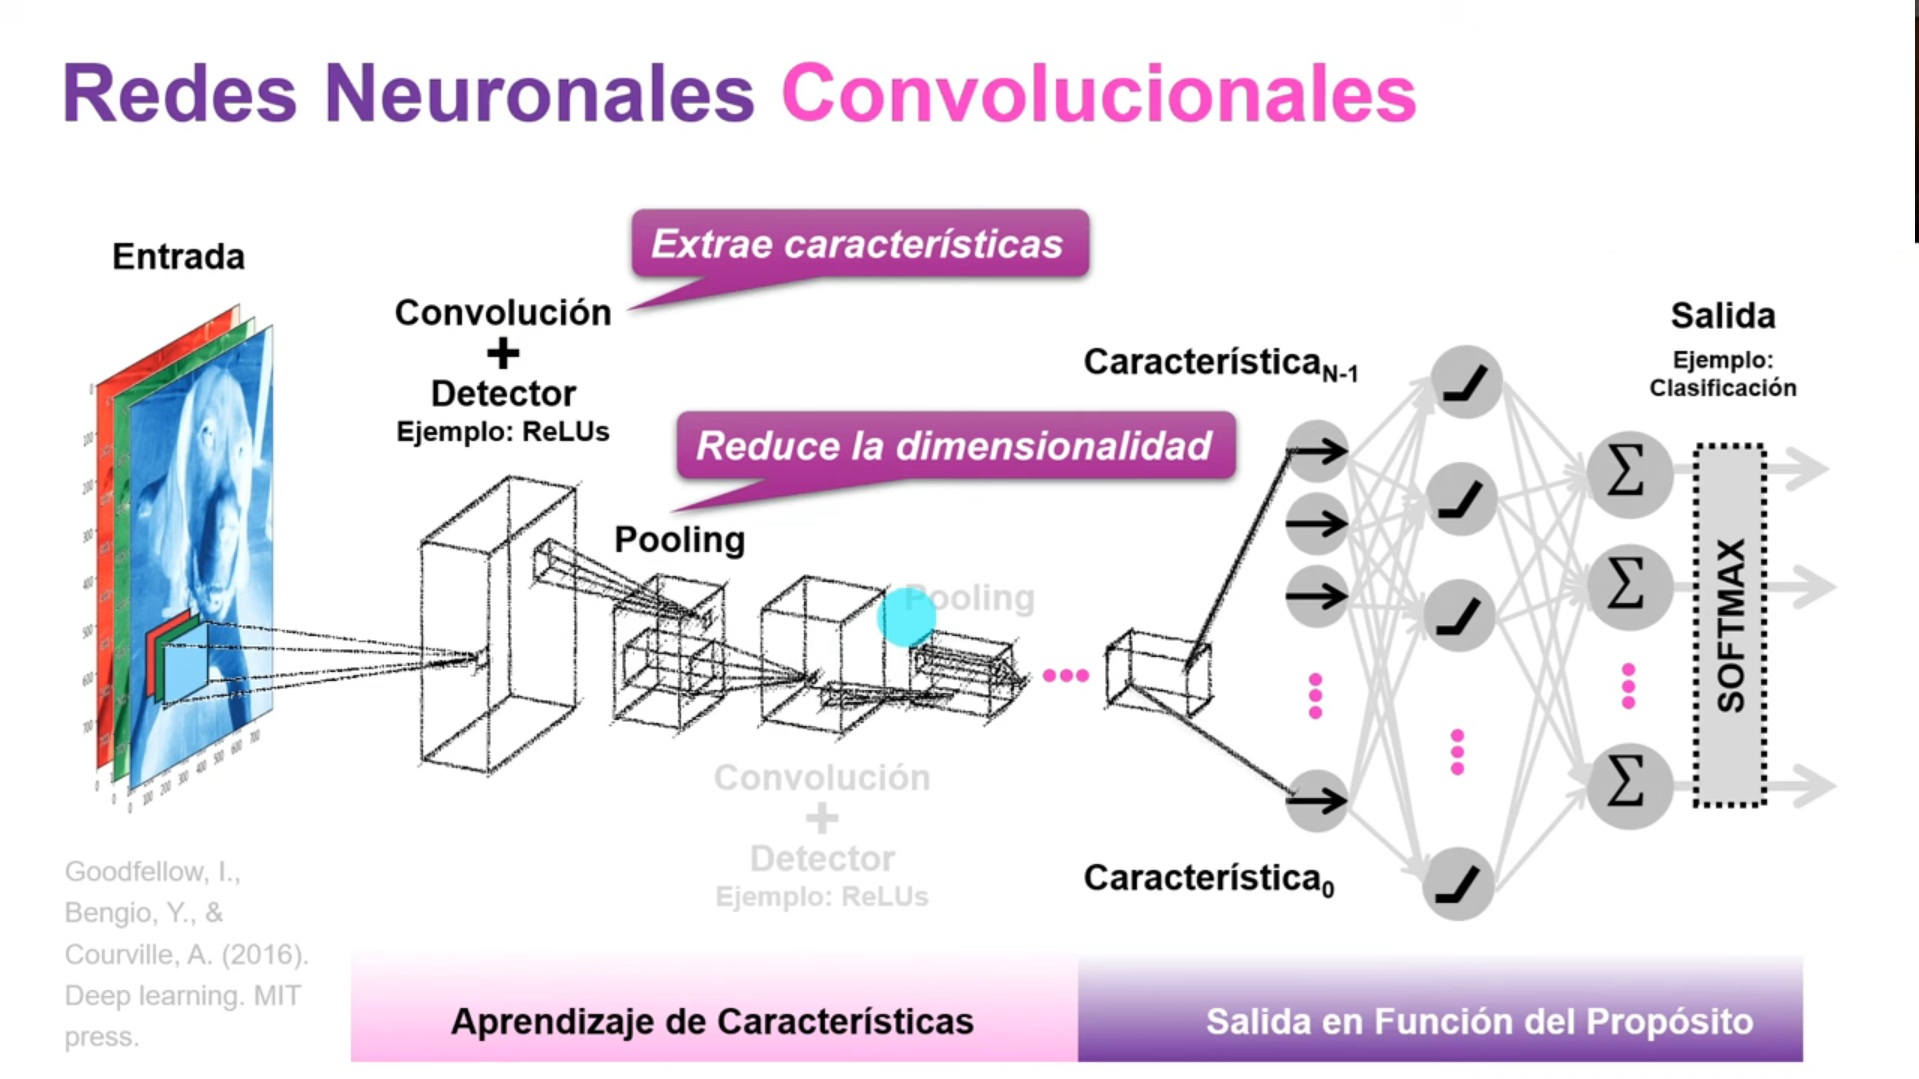

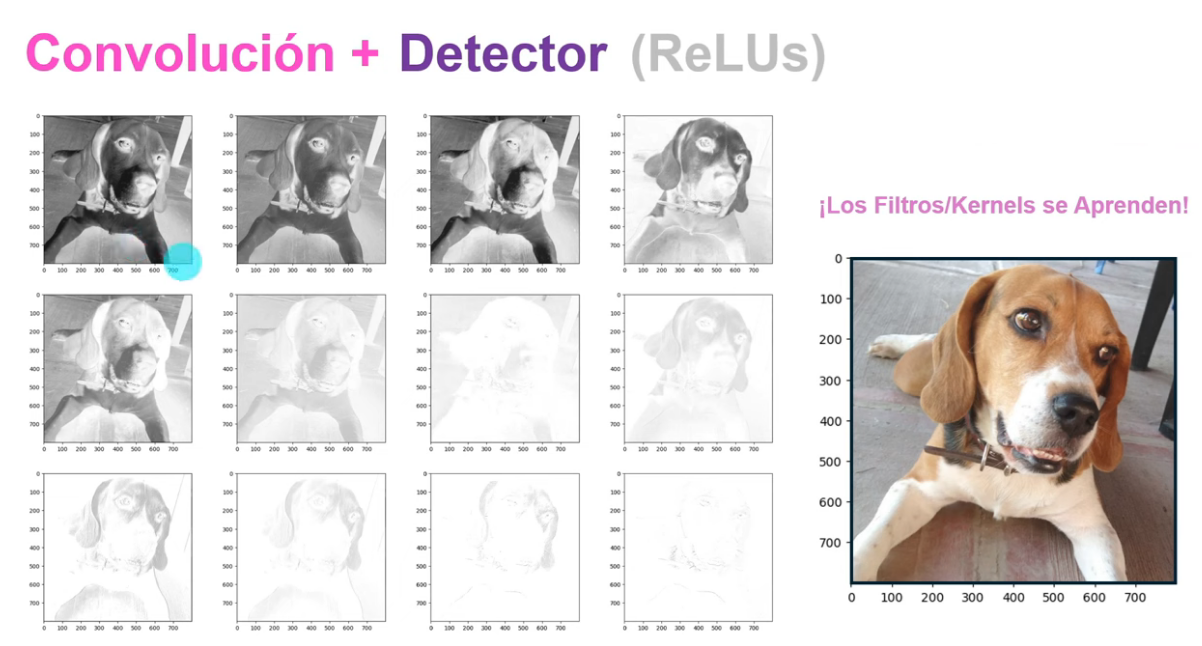

## Table of Contents

<div class="alert alert-block alert-info" style="margin-top: 20px">

<font size = 3>
       
2. <a href="#item2">Import Keras and Packages</a>   

3. <a href="#item3">Convolutional Neural Network with One Convolutional and Pooling Layers</a>  

4. <a href="#item4">Convolutional Neural Network with Two Convolutional and Pooling Layers</a>  

</font>
</div>

## Import Keras and Packages

Let's start by importing the keras libraries and the packages that we would need to build a neural network.

In [ ]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

When working with convolutional neural networks in particular, we will need additional packages.

In [ ]:
from tensorflow.keras.layers import Conv2D # to add convolutional layers
from tensorflow.keras.layers import MaxPooling2D # to add pooling layers
from tensorflow.keras.layers import Flatten # to flatten data for fully connected layers

## Convolutional Layer with two sets of convolutional and pooling layers

We have to reshape and scale data to the format the network expects:

- training images were stored in an array of shape (60000, 28, 28) of type
uint8 with values in the [0, 255] interval.

- In this case, we transform it into a float32 array of shape (60000, 28 , 28, 1) with values between 0 and 1. (in the first MNIST example we used a vector of (60000, 28 * 28) elements instead).
In this case, the Conv2D layer takes as input a tensor of (samples, height, width, channels), where channels is typically 1 (for B/W images) or 3 (for RGB images).

In [ ]:
# import data
from tensorflow.keras.datasets import mnist

# load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape)

# reshape to be [samples][pixels][width][channels]
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')
print(X_train.shape)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000, 28, 28, 1)


Let's normalize the pixel values to be between 0 and 1

In [ ]:
X_train = X_train / 255 # normalize training data
X_test = X_test / 255 # normalize test data

Next, let's convert the target variable into binary categories

In [ ]:
print(y_train.shape)
print(y_train[0])

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print(y_train.shape)
print(y_train[0])

num_classes = y_test.shape[1] # number of categories

(60000,)
5
(60000, 10)
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


Next, let's define a function that creates our model. Let's start with one set of convolutional and pooling layers.

**Conv2D:** realiza una operación de convolución. Extrae caracteristicas
- **filters**: nº de neuronas de la capa Conv2D. Si tenemos 16 neuronas, obtendremos 16 **mapas de caracteristicas**.
- **kernel_size**: tamaño del kernel
- **strides**: desplazamiento del kernel (con solapamiento)
- **input_shape**: dimensionn de los datos de entrada


**Maxpooling:** realiza una operacionde pooling, quedandose con el pixel con el valor más alto. Reduce la dimensionalidad, y se queda con las características más relevantes, lo que ayuda a la red a generalizar mejor. Además conservamos los mapas de caracteristicas de la Conv2D anterior, almacenando cada mapa de caracteristicas en un canal de profundidad de la capa MaxPooling.
- **pool_size**: tamaño de la matriz de pooling
- **strides**: desplazamiento del kernel (sin solapamiento)

In [ ]:
def convolutional_model():

    # create model
    model = Sequential()
    model.add(Conv2D(filters=16, kernel_size=(5, 5), strides=(1, 1), activation='relu', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

    model.add(Flatten())
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    # compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy',  metrics=['accuracy'])
    return model

Finally, let's call the function to create the model, and then let's train it and evaluate it.

**BATCH-SIZE**:

Batch-size =
- El más grande que te quepa en memoria
- En un rango práctico (32–512)
- Equilibrando: velocidad por época ↔ ruido de gradiente ↔ generalización

Prueba distintos valores (32, 64, 128, 200, 256…) y elige el que te dé mejor convergencia y uso de hardware.


- El **batch-size** está casi siempre limitado por la RAM/GPU: elige el valor más grande que quepa sin que explote tu tarjeta.

- Batch pequeño (p.ej. 32–64) → más pasos de actualización por época, más “ruido” en el gradiente ⇒ a menudo mejor generalización, pero más overhead de cómputo.

- Batch grande (128–512+) → menos pasos por época, gradiente más estable, menos overhead, pero puede “sobreajustarse” ligeramente y requerir lr más alta.



In [ ]:
# build the model
model = convolutional_model()

# fit the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=200, verbose=2)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
300/300 - 11s - 36ms/step - accuracy: 0.9216 - loss: 0.2812 - val_accuracy: 0.9695 - val_loss: 0.0992
Epoch 2/10
300/300 - 1s - 5ms/step - accuracy: 0.9750 - loss: 0.0852 - val_accuracy: 0.9776 - val_loss: 0.0680
Epoch 3/10
300/300 - 1s - 4ms/step - accuracy: 0.9818 - loss: 0.0604 - val_accuracy: 0.9813 - val_loss: 0.0573
Epoch 4/10
300/300 - 1s - 4ms/step - accuracy: 0.9859 - loss: 0.0466 - val_accuracy: 0.9857 - val_loss: 0.0459
Epoch 5/10
300/300 - 2s - 5ms/step - accuracy: 0.9887 - loss: 0.0378 - val_accuracy: 0.9841 - val_loss: 0.0509
Epoch 6/10
300/300 - 1s - 5ms/step - accuracy: 0.9898 - loss: 0.0319 - val_accuracy: 0.9867 - val_loss: 0.0397
Epoch 7/10
300/300 - 1s - 4ms/step - accuracy: 0.9917 - loss: 0.0263 - val_accuracy: 0.9872 - val_loss: 0.0397
Epoch 8/10
300/300 - 1s - 4ms/step - accuracy: 0.9933 - loss: 0.0214 - val_accuracy: 0.9876 - val_loss: 0.0375
Epoch 9/10
300/300 - 1s - 4ms/step - accuracy: 0.9941 - loss: 0.0182 - val_accuracy: 0.9879 - val_loss: 0.0359

In [ ]:
# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {scores[1]*100}% \n Test Error: {100-scores[1]*100}%")

Test Accuracy: 98.76999855041504% 
 Test Error: 1.230001449584961%


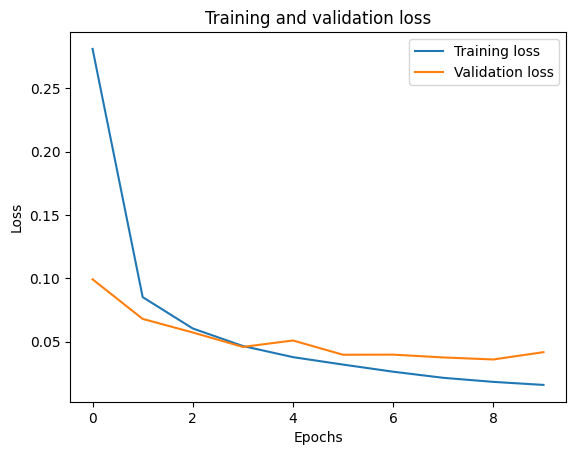

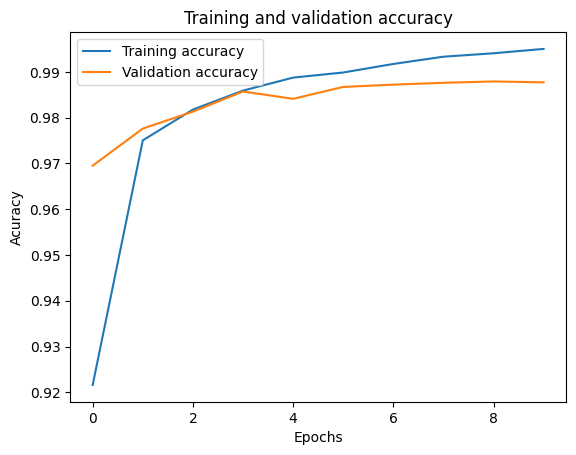

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Acuracy')
plt.legend()
plt.show()

From the figures, we can observe that our model suffers from overfitting, because, starting from epoch 3 accuracy on the training dataset continues improving, however, accuracy on the validation dataset basically does not improve (and typically, would even decay).

Remember: when loss/accuracy does not improve over time on the validation dataset (or, even they begin to get worse), while the model keeps learning (improving) on the training dataset, it is a clear sign of overfitting.

------------------------------------------

## Convolutional Layer with two sets of convolutional and pooling layers

Let's redefine our convolutional model so that it has two convolutional and pooling layers instead of just one layer of each.

In [ ]:
def convolutional_model():

    # create model
    model = Sequential()

    # 16 filters of size: (5x5 pixels + bias)
    model.add(Conv2D(16, (5, 5), activation='relu', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

    # 8 filters of size: (2x2x16 pixels + bias)
    model.add(Conv2D(8, (2, 2), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

    model.add(Flatten())
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    # Compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy',  metrics=['accuracy'])
    return model

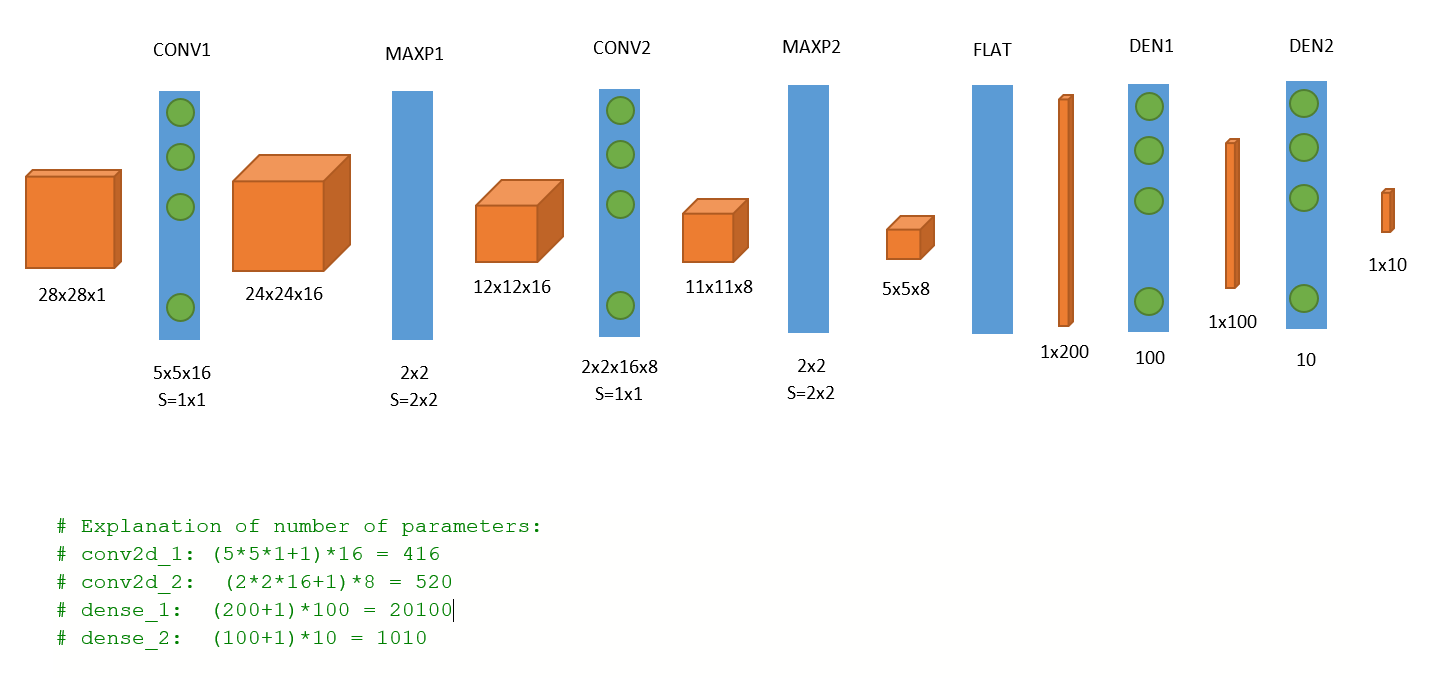

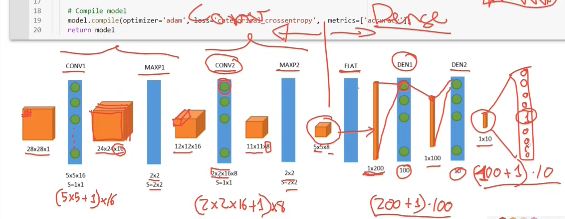

Now, let's call the function to create our new convolutional neural network, and then let's train it and evaluate it.

In [ ]:
# build the model
model = convolutional_model()

# print the model architecture
model.summary()
# explanation of number of parameters:
# conv2d_1: 16*(5*5*1+1) = 416
# conv2d_2: 8*(2*2*16+1) = 520

# fit the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=200, verbose=2)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 8)      │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,046 (86.12 KB)

 Trainable params: 22,046 (86.12 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
300/300 - 5s - 18ms/step - accuracy: 0.8588 - loss: 0.4925 - val_accuracy: 0.9607 - val_loss: 0.1354
Epoch 2/10
300/300 - 1s - 4ms/step - accuracy: 0.9639 - loss: 0.1222 - val_accuracy: 0.9746 - val_loss: 0.0864
Epoch 3/10
300/300 - 1s - 4ms/step - accuracy: 0.9734 - loss: 0.0874 - val_accuracy: 0.9805 - val_loss: 0.0651
Epoch 4/10
300/300 - 1s - 4ms/step - accuracy: 0.9777 - loss: 0.0719 - val_accuracy: 0.9813 - val_loss: 0.0607
Epoch 5/10
300/300 - 1s - 4ms/step - accuracy: 0.9815 - loss: 0.0606 - val_accuracy: 0.9864 - val_loss: 0.0458
Epoch 6/10
300/300 - 1s - 4ms/step - accuracy: 0.9835 - loss: 0.0537 - val_accuracy: 0.9837 - val_loss: 0.0475
Epoch 7/10
300/300 - 1s - 4ms/step - accuracy: 0.9847 - loss: 0.0487 - val_accuracy: 0.9879 - val_loss: 0.0395
Epoch 8/10
300/300 - 1s - 4ms/step - accuracy: 0.9867 - loss: 0.0435 - val_accuracy: 0.9857 - val_loss: 0.0424
Epoch 9/10
300/300 - 2s - 5ms/step - accuracy: 0.9876 - loss: 0.0385 - val_accuracy: 0.9882 - val_loss: 0.0369


In [ ]:
# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {scores[1]*100}% \n Test Error: {100-scores[1]*100}%")

Test Accuracy: 98.78000020980835% 
 Test Error: 1.2199997901916504%


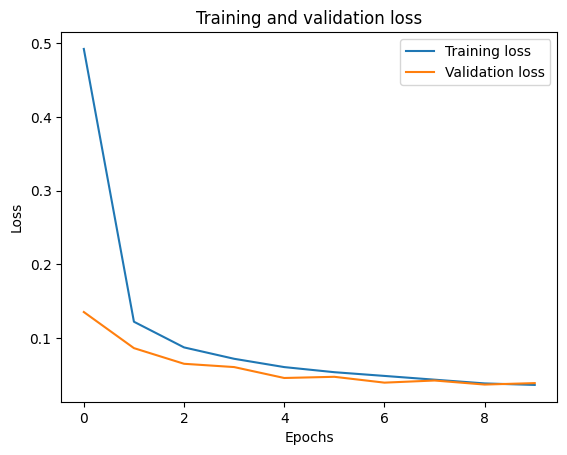

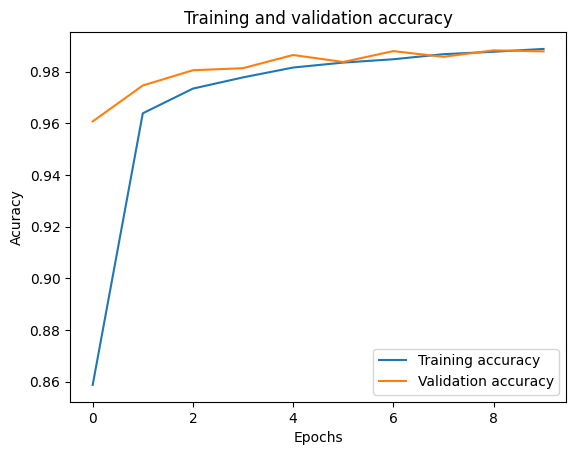

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Acuracy')
plt.legend()
plt.show()

In this case, the overall accuracy is a bit worse than in the first model. However, this second model does not suffers from overfitting, because the accuracy keeps improving both on the training and on the validation dataset.

# Using our model to make predictions

The original tutorial does not include this fundamental part of the developing flow: putting the model to work.

In this case, we will predict the clasification scores for one of the inputs used for testing for simplicity, althought new images should be used in a real scenario.

(28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step
[[2.4785740e-08 2.3378902e-06 4.6429941e-06 7.2106934e-04 3.8794116e-03
  1.1247041e-05 9.5839503e-10 3.0210711e-05 1.5720832e-05 9.9533534e-01]]


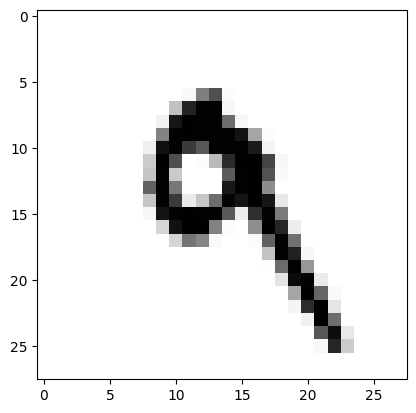

In [ ]:
import matplotlib.pyplot as plt

# imshow needs a 2D array for plotting greyscale images,
# for RGB images the 3rd dim shoud be 3 (not 1 as in this case)
number_img = X_test[7,:,:,0]
print(number_img.shape)
plt.imshow(number_img, cmap='Greys')

# however, predict method takes as input a 4D array (samples,height,width,ch),
# so you have to select a slice of (just one) images (hence the 7:8 instead of 7)
prediction = model.predict(X_test[7:8,:,:,:])
print(prediction)

As expected, prediction takes the highest value for the class"9", and very low values for the rest.

# Confusion matrix

The confusion matrix is another metric for evaluating the performance (accuracy) of our model.

For a given test dataset, the confusion matrix shows the number of input data that have been correctly classified  (and, if not correctly classified, the assigned erroneous class).


To create the confusion matrix we first need the predictions for the test dataset:

In [ ]:
predictions = model.predict(X_test)
print(predictions.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(10000, 10)


In [ ]:
print(predictions[7]) # print prediction for 7th test sample (the "9" used before)

import numpy as np
np.argmax(predictions[7]) # argmax returs the index of the maximun value in the array.

[2.4785693e-08 2.3378902e-06 4.6429855e-06 7.2106830e-04 3.8794065e-03
 1.1247019e-05 9.5839503e-10 3.0210684e-05 1.5720832e-05 9.9533534e-01]


np.int64(9)

### Confusion matrix in tensorflow 2.x.x

In **tensorflow 2.x.x the confusion matrix** is much straight forward to obtain with just a single line of code.

The confusion matrix is always a 2-D array of shape [n, n],
 where n is the number of valid labels for a given classification task. Both
 prediction and labels must be 1-D arrays of the same shape in order for this
 function to work.

In [ ]:
# however, remember that labels and predictions are now one-hot encoded
print(y_test.shape)
print(predictions.shape)

(10000, 10)
(10000, 10)


In [ ]:
# we need to convert them back to cathegorical values to apply tensorflow.math.confusion_matrix
y = np.argmax(y_test, axis=1)
pred = np.argmax(predictions, axis=1)
print(y.shape)
print(y)
print(pred.shape)
print(pred)

(10000,)
[7 2 1 ... 4 5 6]
(10000,)
[7 2 1 ... 4 5 6]


In [ ]:
my_conf_matrix = tensorflow.math.confusion_matrix(y, pred)
my_conf_matrix

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 977,    1,    0,    0,    0,    0,    1,    1,    0,    0],
       [   0, 1133,    1,    0,    0,    0,    0,    1,    0,    0],
       [   2,    1, 1019,    1,    1,    0,    0,    8,    0,    0],
       [   0,    0,    2,  998,    0,    1,    0,    8,    1,    0],
       [   0,    0,    1,    0,  972,    0,    1,    1,    0,    7],
       [   2,    0,    0,    8,    0,  876,    2,    1,    1,    2],
       [   6,    2,    0,    0,    2,    2,  945,    0,    1,    0],
       [   0,    1,    3,    2,    0,    0,    0, 1021,    1,    0],
       [   6,    0,    5,    0,    2,    0,    1,   11,  946,    3],
       [   1,    2,    0,    3,    2,    0,    0,   10,    0,  991]],
      dtype=int32)>

In [ ]:
# or use the classical sklearn function:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y, pred))
print(classification_report(y, pred, digits=4))

[[ 977    1    0    0    0    0    1    1    0    0]
 [   0 1133    1    0    0    0    0    1    0    0]
 [   2    1 1019    1    1    0    0    8    0    0]
 [   0    0    2  998    0    1    0    8    1    0]
 [   0    0    1    0  972    0    1    1    0    7]
 [   2    0    0    8    0  876    2    1    1    2]
 [   6    2    0    0    2    2  945    0    1    0]
 [   0    1    3    2    0    0    0 1021    1    0]
 [   6    0    5    0    2    0    1   11  946    3]
 [   1    2    0    3    2    0    0   10    0  991]]
              precision    recall  f1-score   support

           0     0.9829    0.9969    0.9899       980
           1     0.9939    0.9982    0.9960      1135
           2     0.9884    0.9874    0.9879      1032
           3     0.9862    0.9881    0.9871      1010
           4     0.9928    0.9898    0.9913       982
           5     0.9966    0.9821    0.9893       892
           6     0.9947    0.9864    0.9906       958
           7     0.9614    0.9932   

<Axes: >

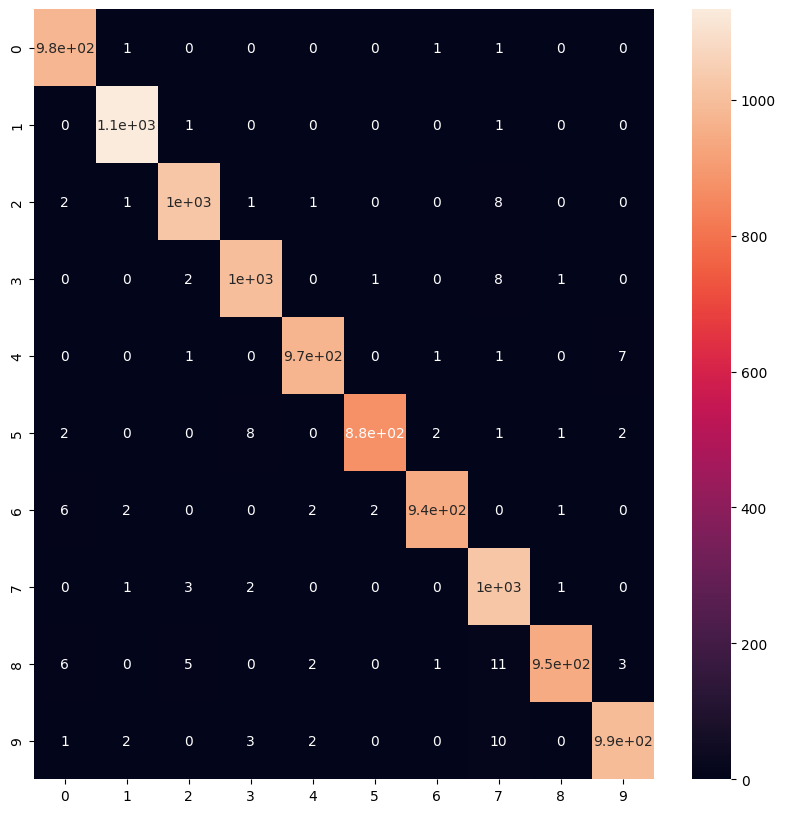

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
sns.heatmap(my_conf_matrix, annot=True)

## Compute accuracy percentage on the test dataset:

There are several metrics that can be extracted from the confusion matrix, just read https://en.wikipedia.org/wiki/Confusion_matrix. The most used are:

- sensitivity (recall, or true positive rate): $TPR=\frac{TP}{TP+FN}$
- specificity (selectivity or true negative rate): $TNR=\frac{TN}{TN+FP}$
- precision (positive predictive value): $PPV=\frac{TP}{TP+FP}$
- accuracy: $ACC=\frac{TP+TN}{TP+TN+FP+FN}$

here: TP = True positive; FP = False positive; TN = True negative; FN = False negative.

However, for simplicity, In this case, let's just calculate the  **accuracy for each of the cathegories** of the test dataset in terms of the **percentage of the samples that where correctly classificated** from the total of samples in that category. It has to be considered though that as Wikipedia itself states, this definition of "Accuracy is not a reliable metric for the real performance of a classifier, because it will yield misleading results if the data set is unbalanced".




In [ ]:
import numpy as np
Y_true_class_max = np.max(my_conf_matrix, axis=0)
print(Y_true_class_max)
Y_true_class_sum = np.sum(my_conf_matrix, axis=1)
print(Y_true_class_sum)
accuracy_percentage = Y_true_class_max/Y_true_class_sum
print(accuracy_percentage)

[ 977 1133 1019  998  972  876  945 1021  946  991]
[ 980 1135 1032 1010  982  892  958 1028  974 1009]
[0.99693878 0.99823789 0.9874031  0.98811881 0.9898167  0.98206278
 0.98643006 0.99319066 0.97125257 0.98216056]


From the results, it could be derived that "0" and "1" are the most recognisable digits, however, "7" is the most difficult to distinguish.

# To probe further

Test this model for the MNIST application, and train it for just 5 epochs with a batch size of 64 images.

    model = models.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer='rmsprop',    
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

What are the results?

In [ ]:
from tensorflow.keras import datasets, models, layers
from tensorflow.keras.utils import to_categorical

In [ ]:
# Cargamos mnist
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

In [ ]:
# preprocesamos (algo muy simple)

x_train = x_train.reshape((60000, 28, 28, 1)).astype("float32") / 255.0
x_test = x_test.reshape((10000, 28, 28, 1)).astype("float32") / 255.0
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
# definimos el modelo (el código ya venía arriba)

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
                        input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# entrenamos 5 epochs con el lote de 64 img
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9376 - loss: 0.1963 - val_accuracy: 0.9842 - val_loss: 0.0536
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9837 - loss: 0.0521 - val_accuracy: 0.9898 - val_loss: 0.0373
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9888 - loss: 0.0351 - val_accuracy: 0.9907 - val_loss: 0.0361
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9918 - loss: 0.0256 - val_accuracy: 0.9907 - val_loss: 0.0361
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9937 - loss: 0.0192 - val_accuracy: 0.9928 - val_loss: 0.0319


In [ ]:
# evaluamos en test
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", test_acc)

Test accuracy: 0.989799976348877


Pues como observamos, obtenemos un accuracy de más del 98% en solo 5 epochs


This notebook is partially inspired by materials extracted from:

This notebook is part of a course on **edX** called *Deep Learning Fundamentals with Keras*. If you accessed this notebook outside the course, you can take this course online by clicking [here](http://cocl.us/DL0101EN_edX_Week4_LAB1).

<hr>

Copyright &copy; 2018 [IBM Developer Skills Network](https://cognitiveclass.ai/?utm_source=bducopyrightlink&utm_medium=dswb&utm_campaign=bdu). This notebook and its source code are released under the terms of the [MIT License](https://bigdatauniversity.com/mit-license/).